In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage.filters import gaussian_filter
import seaborn as sns
import pandas as pd

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_98294/3939165957.py:4: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


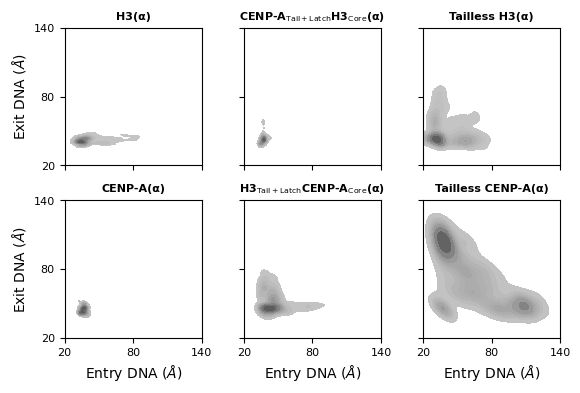

In [6]:
def myplot(x, y, s, bins=1000):
	heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
	heatmap = gaussian_filter(heatmap, sigma=s)

	extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
	return heatmap.T, extent

# List of filenames for entry and exit data pairs along with individual subplot titles and colors
file_pairs = [
	("CSH3-dist-ete_entry.dat",		        "CSH3-dist-ete_exit.dat",			    'C7',		"H3(\u03B1)"),		                     #'C0'),
	("CSltH3core-dist-ete_entry.dat",	    "CSltH3core-dist-ete_exit.dat",		    'C7',		"CENP-A$_{\\mathrm{Tail+Latch}}$H3$_{\\mathrm{Core}}$(\u03B1)"),    #'C2'),
	("CSexnotailH3-dist-ete_entry.dat",	    "CSexnotailH3-dist-ete_exit.dat",		'C7',		"Tailless H3(\u03B1)"),			         #'C4'),
	("CScenpa-dist-ete_entry.dat",	     	"CScenpa-dist-ete_exit.dat",		    'C7',		"CENP-A(\u03B1)"),	                     #'C1'),
	("CSltcenpacore-dist-ete_entry.dat",    "CSltcenpacore-dist-ete_exit.dat",   	'C7',		"H3$_{\\mathrm{Tail+Latch}}$CENP-A$_{\\mathrm{Core}}$(\u03B1)"),    #'C3'),
	("CSexnotailcenpa-dist-ete_entry.dat",	"CSexnotailcenpa-dist-ete_exit.dat",	'C7',		"Tailless CENP-A(\u03B1)"),	             #'C7'),
]

# Custom titles, colors, and overall plot title
subplot_colors = ['C0', 'C2', 'C4', 'C1', 'C3', 'C7']
#overall_plot_title = "End-to-Dyad Distance of DNA Termini"

# Create a single subplot for each pair of files
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
#fig.suptitle(overall_plot_title, fontweight='bold', fontsize=24)

# Axis ticks
ticks = np.arange(20, 141, 60)

for ax, (entry_file, exit_file, subplot_color, subplot_title) in zip(axes.flatten(), file_pairs):
		# Load data
		x = np.loadtxt(entry_file)[:, 1]
		y = np.loadtxt(exit_file)[:, 1]

		# Create DataFrame for seaborn
		df = pd.DataFrame({"Entry DNA ($\AA$)": x, "Exit DNA ($\AA$)": y})

		# Plot KDE density
		sns.kdeplot(data=df, x="Entry DNA ($\AA$)", y="Exit DNA ($\AA$)", fill=True, color=subplot_color, ax=ax)

		# Set title and limits
		ax.set_xlim(20, 140)
		ax.set_ylim(20, 140)
		ax.set_aspect('equal', adjustable='box')
		ax.set_title(subplot_title, fontweight='bold', fontsize=8)

		ticks = range(20,141,60)
		tick_labels = [str(tick) if tick in [20, 80, 140] else '' for tick in ticks]

		# Set ticks and tick labels
		ax.set_xticks(ticks)
		ax.set_xticklabels(tick_labels,  fontsize=8)
		ax.set_yticks(ticks)
		ax.set_yticklabels(tick_labels,  fontsize=8)
		ax.tick_params(axis='both', which='major', labelsize=8)

		# Hide inner labels
		ax.label_outer()

plt.tight_layout()	#rect=[0, 0.03, 1, 0.95])
plt.savefig('AA_asat_etd.pdf')
plt.show()